# Task
Identify building usage profiles, forecast future usage for each profile, and calculate and visualize potential savings using the `admin_building_usage.csv` dataset.

## Load Dataset

### Subtask:
Load the 'admin_building_usage.csv' dataset into a pandas DataFrame.


In [ ]:
import pandas as pd
df = pd.read_csv('/content/admin_building_usage.csv')
df.head()

,timestamp,date,hour,day_of_week,day_name,month,is_weekend,total_kwh,hvac_kwh,lighting_kwh,equipment_kwh,occupancy,temperature_c,humidity_pct
0,2023-01-01 00:00:00,2023-01-01,0,6,Sunday,1,1,31.35,8.84,3.20,4.93,1,7.0,33.2
1,2023-01-01 01:00:00,2023-01-01,1,6,Sunday,1,1,32.54,4.01,3.82,5.85,1,7.4,40.1
2,2023-01-01 02:00:00,2023-01-01,2,6,Sunday,1,1,26.40,6.63,2.42,3.74,2,10.2,32.6
3,2023-01-01 03:00:00,2023-01-01,3,6,Sunday,1,1,29.82,9.01,2.51,5.95,4,10.9,30.7
4,2023-01-01 04:00:00,2023-01-01,4,6,Sunday,1,1,30.74,6.83,2.30,2.66,1,13.9,54.2


## Preprocess Data for Clustering

### Subtask:
Clean and prepare the data for K-means clustering, including handling missing values, selecting relevant features, and scaling the data to define 'usage profiles'.


In [ ]:
selected_features = [
    'total_kwh',
    'hvac_kwh',
    'lighting_kwh',
    'equipment_kwh',
    'hour',
    'day_of_week',
    'is_weekend',
    'month',
    'occupancy',
    'temperature_c',
    'humidity_pct'
]

df_cluster_features = df[selected_features].copy()

print("Missing values in selected features:")
print(df_cluster_features.isnull().sum())

Missing values in selected features:
total_kwh        0
hvac_kwh         0
lighting_kwh     0
equipment_kwh    0
hour             0
day_of_week      0
is_weekend       0
month            0
occupancy        0
temperature_c    0
humidity_pct     0
dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

# No missing values were found, so no imputation is needed.

# Scale the data
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df_cluster_features)
df_scaled = pd.DataFrame(df_scaled_array, columns=df_cluster_features.columns)

print("Scaled DataFrame head:")
print(df_scaled.head())

Scaled DataFrame head:
   total_kwh  hvac_kwh  lighting_kwh  equipment_kwh      hour  day_of_week  \
0  -0.947947 -0.740972     -0.940547      -0.906341 -1.661206     1.499244   
1  -0.924736 -1.195958     -0.800901      -0.789768 -1.516748     1.499244   
2  -1.044500 -0.949154     -1.116230      -1.057125 -1.372290     1.499244   
3  -0.977791 -0.724958     -1.095958      -0.777097 -1.227831     1.499244   
4  -0.959846 -0.930314     -1.143258      -1.193971 -1.083373     1.499244   

   is_weekend     month  occupancy  temperature_c  humidity_pct  
0    1.580676 -1.600699  -0.809454      -1.876459     -1.534009  
1    1.580676 -1.600699  -0.809454      -1.832831     -1.099150  
2    1.580676 -1.600699  -0.785952      -1.527434     -1.571823  
3    1.580676 -1.600699  -0.738949      -1.451085     -1.691567  
4    1.580676 -1.600699  -0.809454      -1.123874     -0.210524  


## Determine Optimal Clusters

### Subtask:
Apply the Elbow Method or a similar technique to determine the optimal number of clusters for K-means clustering on the preprocessed usage data.


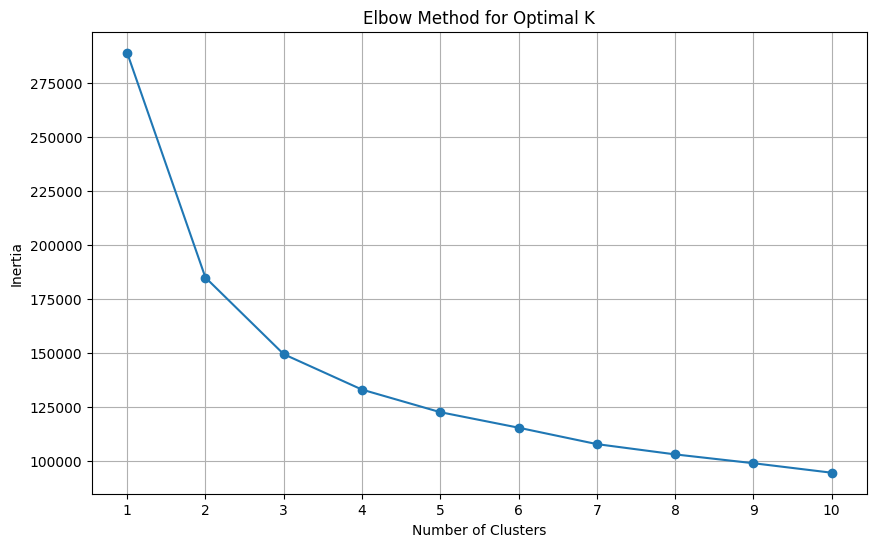

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

# Loop through a range of possible cluster numbers (e.g., from 1 to 10)
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init=10 to suppress warning
    kmeans.fit(df_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia_values, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


## Apply K-Means Clustering

### Subtask:
Apply K-means clustering with the determined optimal number of clusters to segment the building usage data into distinct usage profiles. Assign each data point to its respective cluster.


In [ ]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(df_scaled)

df['cluster'] = kmeans.labels_

print("Distribution of data points across clusters:")
print(df['cluster'].value_counts())

Distribution of data points across clusters:
cluster
1    7548
0    7512
3    6022
2    5199
Name: count, dtype: int64


## Analyze Usage Profiles

### Subtask:
Analyze the characteristics of each identified cluster to understand the different usage profiles. This might involve descriptive statistics or visualizations per cluster.


In [ ]:
cluster_profiles = df.groupby('cluster')[selected_features].mean()
print("Cluster Usage Profiles (Mean of features per cluster):")
print(cluster_profiles)

Cluster Usage Profiles (Mean of features per cluster):
          total_kwh   hvac_kwh  lighting_kwh  equipment_kwh       hour  \
cluster                                                                  
0         44.204035   9.680126      4.189171       6.617090  11.500000   
1        150.661995  30.882583     13.010603      22.593201  11.961314   
2         62.083614  12.683235      6.437819       9.437844  20.107521   
3         51.328753  11.174072      5.098236       8.010998   3.488708   

         day_of_week  is_weekend     month  occupancy  temperature_c  \
cluster                                                                
0           5.501597         1.0  6.552716   8.302316      24.229100   
1           1.997218         0.0  6.503710  94.345257      24.733439   
2           1.992883         0.0  6.470283  17.265436      23.750183   
3           1.997675         0.0  6.529890  11.162405      23.901395   

         humidity_pct  
cluster                
0           57.5719

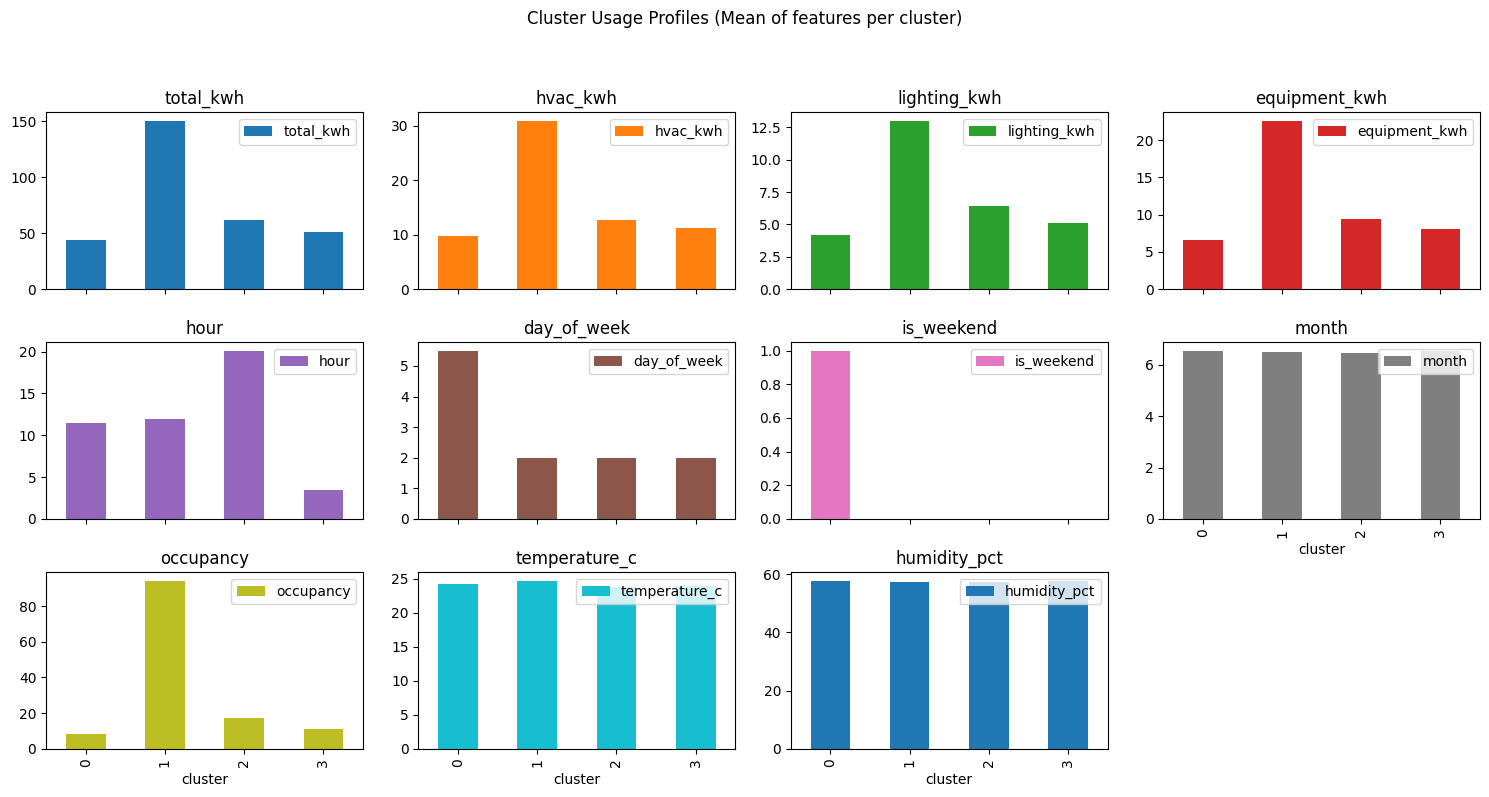

In [ ]:
cluster_profiles.plot(kind='bar', figsize=(15, 8), subplots=True, layout=(3, 4), sharey=False)
plt.suptitle('Cluster Usage Profiles (Mean of features per cluster)', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


## Develop Regression Models for Forecasts

### Subtask:
For each identified cluster, develop and train a regression model to forecast future usage based on the historical data within that cluster. Split the data into training and testing sets for model evaluation.


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

print("Libraries imported: LinearRegression, train_test_split")

Libraries imported: LinearRegression, train_test_split


In [ ]:
cluster_models = {}

# Define features and target variable
features = [
    'hour',
    'day_of_week',
    'is_weekend',
    'month',
    'occupancy',
    'temperature_c',
    'humidity_pct'
]
target = 'total_kwh'

# Iterate through each unique cluster ID
for cluster_id in df['cluster'].unique():
    # Filter data for the current cluster
    cluster_df = df[df['cluster'] == cluster_id].copy()

    # Define X and y
    X = cluster_df[features]
    y = cluster_df[target]

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train Linear Regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Store the trained model
    cluster_models[cluster_id] = {
        'model': model,
        'X_test': X_test,
        'y_test': y_test
    }

    print(f'Model trained for Cluster {cluster_id}')

print("All models trained and stored in 'cluster_models' dictionary.")

Model trained for Cluster 0
Model trained for Cluster 3
Model trained for Cluster 1
Model trained for Cluster 2
All models trained and stored in 'cluster_models' dictionary.


In [ ]:
from sklearn.metrics import r2_score

print("Evaluating models:")
for cluster_id, data in cluster_models.items():
    model = data['model']
    X_test = data['X_test']
    y_test = data['y_test']

    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    print(f"Cluster {cluster_id} - R-squared: {r2:.4f}")

Evaluating models:
Cluster 0 - R-squared: 0.4720
Cluster 3 - R-squared: 0.7445
Cluster 1 - R-squared: 0.2413
Cluster 2 - R-squared: 0.6983


## Calculate Savings Potential

### Subtask:
Based on the forecasts from the regression models, calculate the potential savings. This may involve comparing forecasted usage to a baseline or optimized usage scenario.


In [ ]:
reduction_percentage = 0.10  # 10% reduction

cluster_savings = {}

for cluster_id, data in cluster_models.items():
    model = data['model']
    X_test = data['X_test']
    y_test = data['y_test'] # Although not used for savings calculation, good to keep context

    y_pred = model.predict(X_test)

    # Ensure predictions are not negative
    y_pred[y_pred < 0] = 0

    optimized_usage = y_pred * (1 - reduction_percentage)
    potential_savings = (y_pred - optimized_usage).sum()

    cluster_savings[cluster_id] = potential_savings

total_potential_savings = sum(cluster_savings.values())

print("Potential Savings per Cluster:")
for cluster_id, savings in cluster_savings.items():
    print(f"Cluster {cluster_id}: {savings:.2f} kWh")

print(f"\nTotal Potential Savings: {total_potential_savings:.2f} kWh")

Potential Savings per Cluster:
Cluster 0: 6638.84 kWh
Cluster 3: 6238.70 kWh
Cluster 1: 22782.33 kWh
Cluster 2: 6433.18 kWh

Total Potential Savings: 42093.05 kWh


## Visualize Savings Potential

### Subtask:
Generate pie charts to visualize the calculated savings potential, suitable for a dashboard display. Ensure legends are provided for clarity.


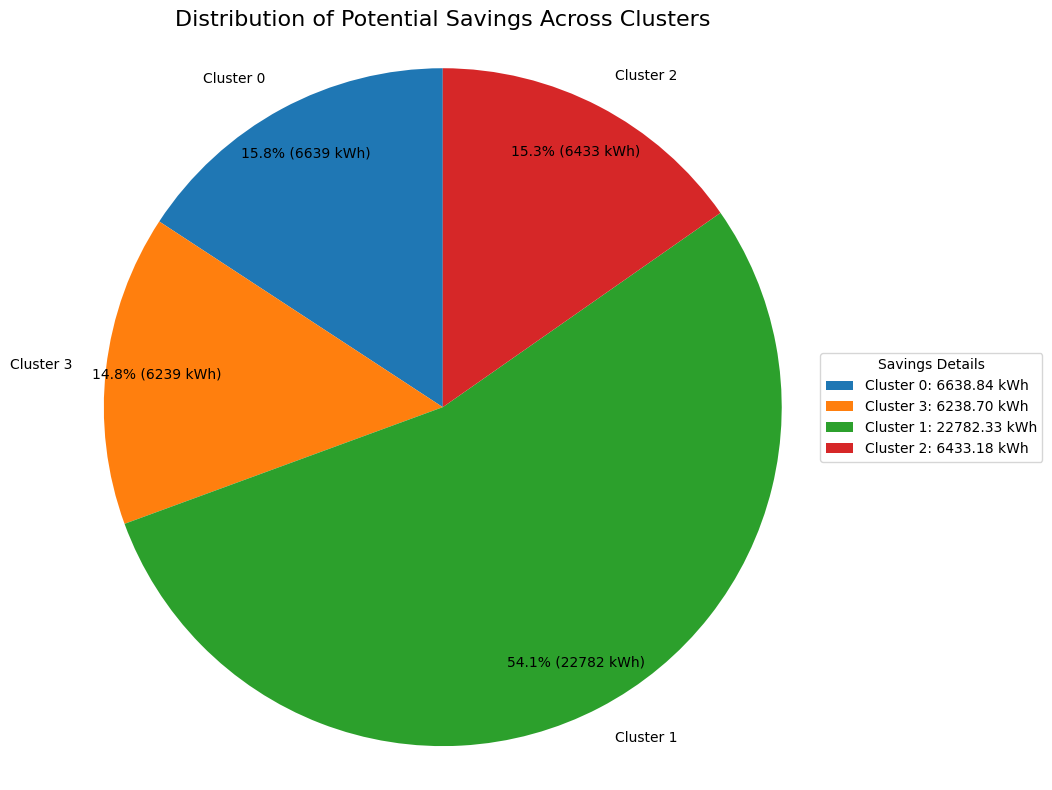

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert cluster_savings dictionary to a Pandas Series
savings_series = pd.Series(cluster_savings)

# Prepare labels and autopct format
labels = savings_series.index.map(lambda x: f'Cluster {x}')
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}% ({val} kWh)'
    return my_format

# Create the pie chart
plt.figure(figsize=(10, 8))
plt.pie(savings_series, labels=labels, autopct=autopct_format(savings_series), startangle=90, pctdistance=0.85)
plt.title('Distribution of Potential Savings Across Clusters', fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Add legend with actual kWh values
legend_labels = [f'{label}: {savings_series.loc[int(label.split()[-1])]:.2f} kWh' for label in labels]
plt.legend(legend_labels, title="Savings Details", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()